In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from PIL import Image
from pycocotools.coco import COCO

In [2]:
# ── Dataset registry ──────────────────────────────────────────────────────────
DATASETS = {
    "dior": {"json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json", "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/train"},
    "dota_v2": {"json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json", "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images"}
}

# ── Settings ──────────────────────────────────────────────────────────────────
DATASET_NAME = "dior"  
SEED         = 88      # Seed tuned for a good structural object
SAVE_PATH    = None    # Set to a path to save the generated image, e.g., "output.png"

# ── Colors & Styling ──────────────────────────────────────────────────────────
COL_BOX     = "#facc15" # Yellow
COL_PTS     = "#06b6d4" # Cyan (High-tech attention points)
COL_SLOW    = "#ef4444" # Red
COL_FAST    = "#22c55e" # Green
COL_DARK    = "#0f172a"

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


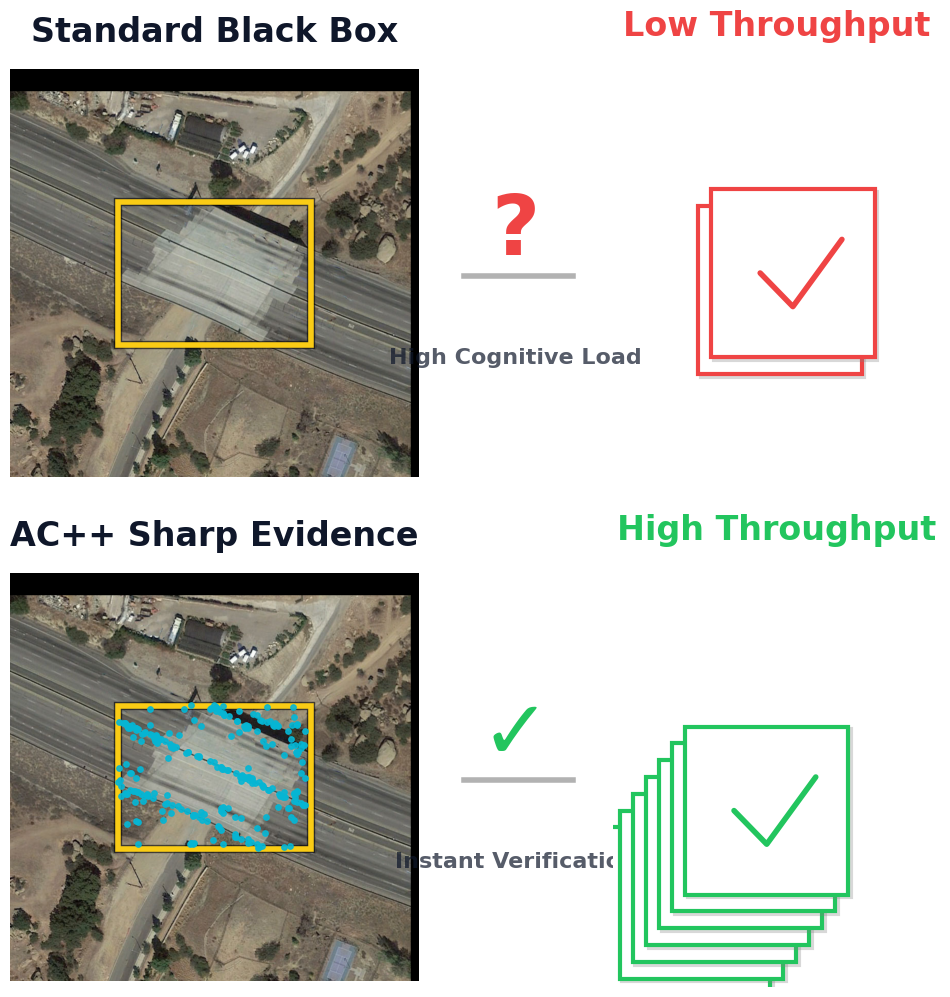

In [3]:
def get_hero_crop(coco, image_folder, seed=None):
    """Finds an image and crops a clean square around its largest object."""
    if seed is not None: random.seed(seed)
    img_ids = coco.getImgIds()
    random.shuffle(img_ids)
    
    for img_id in img_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id)
        if not ann_ids: continue
        
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(image_folder, img_info["file_name"])
        if not os.path.isfile(img_path): continue
        
        annotations = coco.loadAnns(ann_ids)
        largest_ann = max(annotations, key=lambda a: a["bbox"][2] * a["bbox"][3])
        x, y, w, h = largest_ann["bbox"]
        
        if w < 30 or h < 30 or w > img_info['width']*0.6: continue
            
        image = Image.open(img_path).convert("RGB")
        pad = max(w, h) * 1.2
        cx, cy = x + w/2, y + h/2
        
        left, top = max(0, cx - pad), max(0, cy - pad)
        right, bottom = min(image.size[0], cx + pad), min(image.size[1], cy + pad)
        
        act_side = min(right - left, bottom - top)
        left, right = cx - act_side/2, cx + act_side/2
        top, bottom = cy - act_side/2, cy + act_side/2
        
        img_crop = image.crop((int(left), int(top), int(right), int(bottom)))
        new_bbox = [x - left, y - top, w, h]
        return img_crop, new_bbox
    raise RuntimeError("No suitable image found.")

def simulate_ac_plus_plus_points(image, bbox, num_points=250):
    """Simulates sharp MSDA sampling locations by finding object edges."""
    img_np = np.array(image.convert("L")) # Convert to grayscale
    x, y, w, h = [int(v) for v in bbox]
    
    # Extract box area and calculate simple gradients (edges)
    patch = img_np[y:y+h, x:x+w]
    gy, gx = np.gradient(patch.astype(float))
    edges = np.sqrt(gx**2 + gy**2)
    
    # Normalize and create a probability distribution
    edges = np.clip(edges - edges.mean(), 0, None) 
    if edges.sum() == 0: edges += 1 # Fallback
    prob = (edges / edges.sum()).flatten()
    
    # Sample points based on the edge distribution
    indices = np.random.choice(len(prob), size=num_points, p=prob)
    pts_y, pts_x = np.unravel_index(indices, edges.shape)
    
    # Add a little noise to simulate attention scatter, shift back to global coords
    pts_x = pts_x + x + np.random.normal(0, 2, num_points)
    pts_y = pts_y + y + np.random.normal(0, 2, num_points)
    return pts_x, pts_y

def draw_image_stack(ax, x_center, y_center, count, color):
    """Draws a visually appealing stack of verified images."""
    width, height = 2.5, 2.0
    for i in range(count):
        # Stack them diagonally upwards
        offset_x = x_center - (count*0.1) + (i * 0.2)
        offset_y = y_center - (count*0.1) + (i * 0.2)
        
        rect = mpatches.Rectangle((offset_x, offset_y), width, height, 
                                  facecolor="white", edgecolor=color, lw=3, zorder=i,
                                  path_effects=[path_effects.SimpleLineShadow(shadow_color="gray", offset=(2,-2), alpha=0.3), path_effects.Normal()])
        ax.add_patch(rect)
        # Add a little checkmark on the top image
        if i == count - 1:
            ax.plot([offset_x + width*0.3, offset_x + width*0.5, offset_x + width*0.8],
                    [offset_y + height*0.5, offset_y + height*0.3, offset_y + height*0.7],
                    color=color, lw=4, zorder=i+1, solid_capstyle="round", solid_joinstyle="round")

# ── Execution ─────────────────────────────────────────────────────────────────
cfg = DATASETS[DATASET_NAME]
coco = COCO(cfg["json_path"])
image, bbox = get_hero_crop(coco, cfg["image_folder"], seed=SEED)
pts_x, pts_y = simulate_ac_plus_plus_points(image, bbox)

# ── Figure Layout (Strictly Square) ───────────────────────────────────────────
fig = plt.figure(figsize=(12, 12), facecolor="#ffffff")
gs = fig.add_gridspec(2, 3, width_ratios=[1.5, 0.5, 1.2], wspace=0.1, hspace=0.2)

ax_img1 = fig.add_subplot(gs[0, 0])
ax_mid1 = fig.add_subplot(gs[0, 1])
ax_out1 = fig.add_subplot(gs[0, 2])

ax_img2 = fig.add_subplot(gs[1, 0])
ax_mid2 = fig.add_subplot(gs[1, 1])
ax_out2 = fig.add_subplot(gs[1, 2])

def setup_ax(ax):
    ax.axis("off")

for ax in [ax_img1, ax_mid1, ax_out1, ax_img2, ax_mid2, ax_out2]: setup_ax(ax)

# ── Row 1: The Bottleneck (Black Box) ─────────────────────────────────────────
ax_img1.imshow(image)
ax_img1.add_patch(mpatches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], fill=False, edgecolor=COL_BOX, lw=4, path_effects=[path_effects.Stroke(linewidth=6, foreground='black', alpha=0.6), path_effects.Normal()]))
ax_img1.set_xlim(0, image.size[0]); ax_img1.set_ylim(image.size[1], 0)
ax_img1.set_title("Standard Black Box", fontsize=24, fontweight="bold", pad=20, color=COL_DARK)

# Middle icon: High Cognitive Load / Slow
ax_mid1.set_xlim(0, 1); ax_mid1.set_ylim(0, 1)
ax_mid1.text(0.5, 0.6, "?", fontsize=60, fontweight="bold", color=COL_SLOW, ha="center", va="center")
ax_mid1.text(0.5, 0.3, "High Cognitive Load", fontsize=16, fontweight="bold", color=COL_DARK, ha="center", va="center", alpha=0.7)
ax_mid1.plot([0.1, 0.9], [0.5, 0.5], color=COL_SLOW, lw=4, zorder=-1, path_effects=[path_effects.SimpleLineShadow()])

# Output: Low Throughput
ax_out1.set_xlim(0, 5); ax_out1.set_ylim(0, 5)
draw_image_stack(ax_out1, 1.5, 1.5, count=2, color=COL_SLOW)
ax_out1.set_title("Low Throughput", fontsize=24, fontweight="bold", pad=20, color=COL_SLOW)

# ── Row 2: The Multiplier (AC++) ──────────────────────────────────────────────
ax_img2.imshow(image)
ax_img2.add_patch(mpatches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], fill=False, edgecolor=COL_BOX, lw=4, path_effects=[path_effects.Stroke(linewidth=6, foreground='black', alpha=0.6), path_effects.Normal()]))
# Add sharp, structural AC++ points
ax_img2.scatter(pts_x, pts_y, s=15, color=COL_PTS, alpha=0.9, zorder=5)
ax_img2.set_xlim(0, image.size[0]); ax_img2.set_ylim(image.size[1], 0)
ax_img2.set_title("AC++ Sharp Evidence", fontsize=24, fontweight="bold", pad=20, color=COL_DARK)

# Middle icon: Instant / Fast
ax_mid2.set_xlim(0, 1); ax_mid2.set_ylim(0, 1)
ax_mid2.text(0.5, 0.6, "✓", fontsize=60, fontweight="bold", color=COL_FAST, ha="center", va="center")
ax_mid2.text(0.5, 0.3, "Instant Verification", fontsize=16, fontweight="bold", color=COL_DARK, ha="center", va="center", alpha=0.7)
ax_mid2.plot([0.1, 0.9], [0.5, 0.5], color=COL_FAST, lw=4, zorder=-1, path_effects=[path_effects.SimpleLineShadow()])

# Output: High Throughput
ax_out2.set_xlim(0, 5); ax_out2.set_ylim(0, 5)
draw_image_stack(ax_out2, 0.5, 0.5, count=8, color=COL_FAST)
ax_out2.set_title("High Throughput", fontsize=24, fontweight="bold", pad=20, color=COL_FAST)

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
    print(f"Schematic saved to {SAVE_PATH}")

plt.show()

AttributeError: FancyArrowPatch.set() got an unexpected keyword argument 'widthB'

/data/mburges/miniconda/envs/albackbone/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/data/mburges/miniconda/envs/albackbone/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/data/mburges/miniconda/envs/albackbone/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/mburges/miniconda/envs/albackbone/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


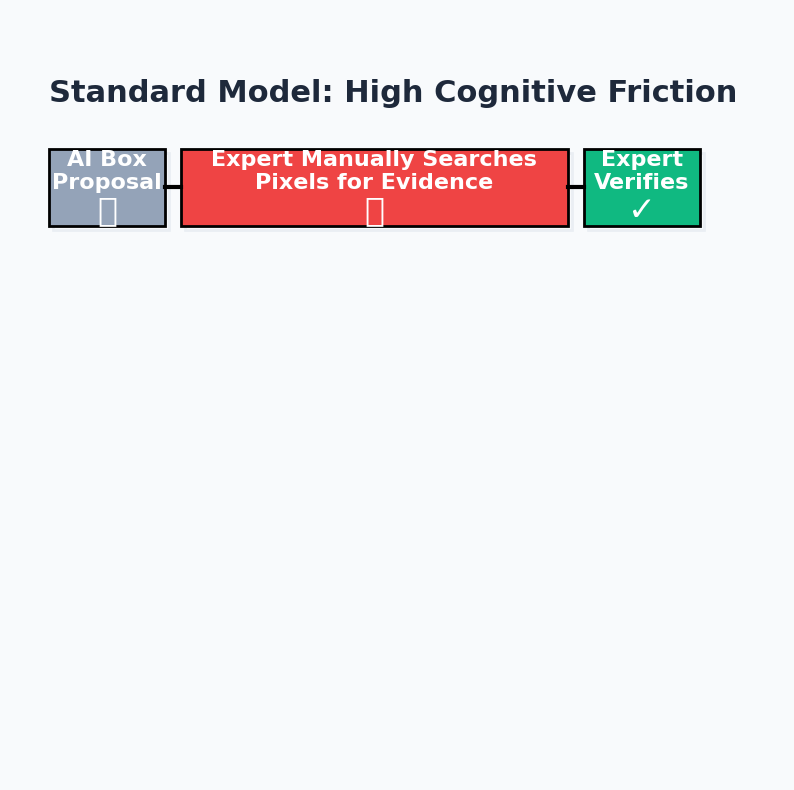

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects

# ── Settings & Colors (Slide Optimized) ───────────────────────────────────────
SAVE_PATH    = "xai_throughput_timeline.png"
COL_AI       = "#94a3b8"  # Slate (AI processing time)
COL_SEARCH   = "#ef4444"  # Red (Wasted cognitive time searching for evidence)
COL_DECIDE   = "#10b981"  # Green (Expert making the actual decision)
COL_BG       = "#f8fafc"
FONT_TITLE   = 22
FONT_LABEL   = 16

fig, ax = plt.subplots(figsize=(10, 10), facecolor=COL_BG)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Helper to draw horizontal timeline blocks
def draw_block(ax, x, y, width, height, color, label, icon=""):
    rect = mpatches.Rectangle((x, y), width, height, facecolor=color, edgecolor="black", lw=2,
                              path_effects=[path_effects.SimpleLineShadow(shadow_color="#cbd5e1", offset=(3,-3)), path_effects.Normal()])
    ax.add_patch(rect)
    # Text inside block
    ax.text(x + width/2, y + height/2 + 0.2, label, color="white", fontweight="bold", fontsize=FONT_LABEL, ha="center", va="center")
    if icon:
        ax.text(x + width/2, y + height/2 - 0.3, icon, color="white", fontweight="bold", fontsize=FONT_LABEL+8, ha="center", va="center")

# ── Top Section: Standard Black Box (Low Throughput) ──────────────────────────
ax.text(0.5, 8.8, "Standard Model: High Cognitive Friction", fontsize=FONT_TITLE, fontweight="bold", color="#1e293b")

# One long cycle
y_top = 7.2
h = 1.0
draw_block(ax, 0.5, y_top, 1.5, h, COL_AI, "AI Box\nProposal", "🤖")
draw_block(ax, 2.2, y_top, 5.0, h, COL_SEARCH, "Expert Manually Searches\nPixels for Evidence", "🔍")
draw_block(ax, 7.4, y_top, 1.5, h, COL_DECIDE, "Expert\nVerifies", "✓")

# Connection lines
ax.plot([2.0, 2.2], [y_top+h/2, y_top+h/2], color="black", lw=3)
ax.plot([7.2, 7.4], [y_top+h/2, y_top+h/2], color="black", lw=3)

# Output brace indicating 1 image processed
ax.annotate('1 Image Verified', xy=(4.7, 6.9), xytext=(4.7, 6.2),
            fontsize=FONT_LABEL, fontweight="bold", ha='center', color="#475569",
            arrowprops=dict(arrowstyle='-[', widthB=8.0, lengthB=0.5, lw=2, color="#64748b"))

# ── Divider ───────────────────────────────────────────────────────────────────
ax.axhline(5.5, color="#cbd5e1", lw=3, linestyle="--")

# ── Bottom Section: AC++ Explainability (High Throughput) ─────────────────────
ax.text(0.5, 4.5, "AC++ Framework: Frictionless Verification", fontsize=FONT_TITLE, fontweight="bold", color="#1e293b")

y_bot = 2.9
# Multiple fast cycles fitting in the same timeframe
for i in range(3):
    start_x = 0.5 + (i * 3.1)
    draw_block(ax, start_x, y_bot, 1.5, h, COL_AI, "AI Box +\nAC++ Evidence", "🤖+🎯")
    # Notice the Red "Search" block is completely eliminated
    draw_block(ax, start_x + 1.7, y_bot, 1.2, h, COL_DECIDE, "Expert\nVerifies", "✓")
    ax.plot([start_x + 1.5, start_x + 1.7], [y_bot+h/2, y_bot+h/2], color="black", lw=3)
    
    if i < 2: # Line to next image
        ax.plot([start_x + 2.9, start_x + 3.1], [y_bot+h/2, y_bot+h/2], color="black", lw=3, linestyle=":")

# Output brace indicating 3 images processed
ax.annotate('3x Images Verified (Same Quality, Higher Quantity)', xy=(4.7, 2.6), xytext=(4.7, 1.9),
            fontsize=FONT_LABEL, fontweight="bold", ha='center', color=COL_DECIDE,
            arrowprops=dict(arrowstyle='-[', widthB=8.0, lengthB=0.5, lw=2, color=COL_DECIDE))

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
    print(f"Schematic saved to {SAVE_PATH}")

plt.show()